# Tema D · Anualidades, Perpetuidades y Ecuaciones de Valor

**Curso: Matemáticas Financieras** — Notebook de aplicación práctica

Este notebook cubre el **Tema D del temario**:

- Anualidades (vencidas/ordinarias y anticipadas): valor presente, valor futuro y renta
- Anualidades diferidas
- Perpetuidades
- Equivalencia entre tasas de interés y tasas de descuento
- Ecuaciones de valor

Y lo lleva a **casos de análisis empresarial y de inversiones**: tablas de amortización
de créditos, valuación de bonos, planeación de metas de ahorro/retiro, evaluación de
proyectos de inversión (VPN) y valuación de acciones con crecimiento (modelo de Gordon).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


## ¿Qué es una anualidad?

Una anualidad es una serie de pagos realizados a intervalos iguales y por la misma
cantidad. Existen dos tipos:

- **Anualidad vencida (ordinaria)**: los pagos se hacen **al final** de cada periodo
  (p.ej. el pago de un bono, una mensualidad de crédito que se paga a fin de mes).
- **Anualidad anticipada**: los pagos se hacen **al inicio** de cada periodo (p.ej. la
  renta de un inmueble, que suele pagarse por adelantado).


## Valor presente de una anualidad vencida

$$
PV = R \cdot \left(\frac{1-(1+i)^{-n}}{i}\right)
$$

Donde $R$ es la renta (pago) periódica, $i$ la tasa periódica y $n$ el número de pagos.
Al término $\left(\frac{1-(1+i)^{-n}}{i}\right)$ se le llama **factor de anualidad**.


In [2]:
def factor_anualidad_vencida(i, n):
    '''Factor de anualidad vencida: (1-(1+i)^-n)/i'''
    return (1 - (1 + i) ** -n) / i


def valor_presente_anualidad_vencida(R, i, n, fv_adicional=0.0):
    '''PV de una anualidad vencida; permite sumar un pago único adicional (p.ej. valor
    nominal de un bono) que se descuenta al final del periodo n.'''
    return R * factor_anualidad_vencida(i, n) + fv_adicional / (1 + i) ** n


def renta_desde_pv(PV, i, n):
    '''Despeje de la renta a partir del valor presente.'''
    return PV / factor_anualidad_vencida(i, n)


### Ejercicio (slides): precio de contado de un bien financiado

> ¿Cuál será el precio de contado de un bien por el cual se pagan \$10,000 mensuales
> durante 60 meses si la tasa de interés del mercado es del 15%? ¿Cuál es el factor de
> anualidad?

Resultado esperado: **factor ≈ 42.03**, **PV ≈ \$420,345.92**.


In [3]:
i_mensual = 0.15 / 12
n = 60
R = 10_000

factor = factor_anualidad_vencida(i_mensual, n)
pv = valor_presente_anualidad_vencida(R, i_mensual, n)

print(f"Factor de anualidad: {factor:.6f}")
print(f"Valor presente: {pv:,.2f}")
assert round(factor, 2) == 42.03
assert round(pv, 2) == 420_345.92
print("OK: coincide con las slides.")


Factor de anualidad: 42.034592
Valor presente: 420,345.92
OK: coincide con las slides.


### Ejercicio (slides): anualidad vencida + pago único al final (valuación tipo bono)

> ¿Cuánto tendría que pagar hoy por un instrumento que me paga \$50 USD trimestralmente
> durante los siguientes 18 trimestres (tasa anual 9%), y que además paga \$100,000 USD
> adicionales en el último trimestre?

Esta es exactamente la lógica de **valuar un bono**: valor presente de los cupones
(anualidad) + valor presente del pago del principal (valor nominal) al vencimiento.


In [4]:
i_trimestral = 0.09 / 4
n = 18
cupon = 50
valor_nominal = 100_000

pv = valor_presente_anualidad_vencida(cupon, i_trimestral, n, fv_adicional=valor_nominal)
print(f"Valor presente total: {pv:,.2f}")
assert round(pv, 0) == 67_731
print("OK: coincide (redondeando) con las slides.")


Valor presente total: 67,731.15
OK: coincide (redondeando) con las slides.


### Cálculo de la renta a partir del valor presente

Despejando la fórmula anterior podemos calcular la **mensualidad** que corresponde a un
crédito o financiamiento dado un valor presente.

> ¿Cuál será la renta que se debe pagar por un bien que vale de contado \$4,500,000 si se
> hacen pagos bimestrales durante los siguientes 3 años con una tasa de interés del 31%?

Resultado esperado: **R ≈ \$389,986.67**.


In [5]:
PV = 4_500_000
i_bimestral = 0.31 / 6
n = 3 * 6  # 3 años en bimestres

R = renta_desde_pv(PV, i_bimestral, n)
print(f"Renta bimestral: {R:,.2f}")
assert round(R, 0) == 389_987
print("OK: coincide con las slides.")


Renta bimestral: 389,986.67
OK: coincide con las slides.


### Caso especial: renta de un crédito considerando IVA

Los intereses de un crédito generan IVA. Para que todos los pagos sean idénticos, se
puede incorporar el efecto del IVA directamente en el factor de anualidad:

$$
R = \frac{PV}{\dfrac{1-\left(1+i\cdot(1+IVA)\right)^{-n}}{i\cdot(1+IVA)}}
$$


In [6]:
def renta_con_iva(PV, i, n, iva=0.16):
    '''Renta de un crédito reconociendo el IVA sobre los intereses.'''
    i_iva = i * (1 + iva)
    factor = (1 - (1 + i_iva) ** -n) / i_iva
    return PV / factor


R_sin_iva = renta_desde_pv(4_500_000, 0.31 / 6, 18)
R_con_iva = renta_con_iva(4_500_000, 0.31 / 6, 18, iva=0.16)
print(f"Renta sin considerar IVA: {R_sin_iva:,.2f}")
print(f"Renta considerando IVA:   {R_con_iva:,.2f}")
print(f"Diferencia mensual por IVA sobre intereses: {R_con_iva - R_sin_iva:,.2f}")


Renta sin considerar IVA: 389,986.67
Renta considerando IVA:   415,396.40
Diferencia mensual por IVA sobre intereses: 25,409.73


## Valor presente de una anualidad anticipada

Con la anualidad anticipada el comprador se "ahorra" un periodo de intereses respecto de
la vencida, porque el primer pago se hace de inmediato:

$$
PV = R \cdot \left(\frac{1-(1+i)^{-n}}{i}\right)\cdot(1+i)
$$


In [7]:
def valor_presente_anualidad_anticipada(R, i, n):
    '''PV de una anualidad anticipada = PV de la vencida * (1+i).'''
    return valor_presente_anualidad_vencida(R, i, n) * (1 + i)


### Ejercicio (slides): precio de contado con enganche

> ¿Cuál será el precio de contado de un bien por el cual di el 30% de enganche y pago
> mensualidades de \$5,000 durante los siguientes 4 años con una tasa de mercado del 15%,
> si el primer pago se hizo al inicio del mes (anualidad anticipada)?

Resultado esperado: **precio total ≈ \$259,861**.


In [8]:
R = 5_000
i_mensual = 0.15 / 12
n = 4 * 12
enganche_pct = 0.30

pv_financiado = valor_presente_anualidad_anticipada(R, i_mensual, n)
precio_total = pv_financiado / (1 - enganche_pct)

print(f"Valor presente de las mensualidades (parte financiada): {pv_financiado:,.2f}")
print(f"Precio de contado total (con 30% de enganche):          {precio_total:,.2f}")
assert round(pv_financiado, 0) == 181_903
assert round(precio_total, 0) == 259_862
print("OK: coincide con las slides.")


Valor presente de las mensualidades (parte financiada): 181,903.12
Precio de contado total (con 30% de enganche):          259,861.60
OK: coincide con las slides.


## Valor futuro de una anualidad vencida

$$
FV = R \cdot \left(\frac{(1+i)^{n}-1}{i}\right)
$$


In [9]:
def factor_anualidad_futura(i, n):
    '''Factor de anualidad (valor futuro): ((1+i)^n - 1)/i'''
    return ((1 + i) ** n - 1) / i


def valor_futuro_anualidad_vencida(R, i, n):
    return R * factor_anualidad_futura(i, n)


def renta_desde_fv(FV, i, n):
    '''Despeje de la renta a partir del valor futuro objetivo.'''
    return FV / factor_anualidad_futura(i, n)


def valor_futuro_anualidad_anticipada(R, i, n):
    '''FV de una anualidad anticipada = FV de la vencida * (1+i).'''
    return valor_futuro_anualidad_vencida(R, i, n) * (1 + i)


### Ejercicio (slides): reposición de maquinaria

> Se hacen depósitos de \$120,000 al bimestre, capitalizando intereses al 17% anual,
> durante los 3 años de vida útil restante de una máquina. ¿Alcanzará para reponerla por
> \$5,000,000? ¿Cuál es el factor de anualidad? (vencida y anticipada)


In [10]:
R = 120_000
i_bimestral = 0.17 / 6
n = 3 * 6  # 3 años en bimestres
meta = 5_000_000

factor_fv = factor_anualidad_futura(i_bimestral, n)
fv_vencida = valor_futuro_anualidad_vencida(R, i_bimestral, n)
fv_anticipada = valor_futuro_anualidad_anticipada(R, i_bimestral, n)

print(f"Factor de anualidad (FV): {factor_fv:.6f}")
print(f"Valor futuro (anualidad vencida):     {fv_vencida:,.2f}")
print(f"Valor futuro (anualidad anticipada):  {fv_anticipada:,.2f}")
print(f"¿Alcanza la meta de {meta:,.0f}? {'Sí' if fv_vencida >= meta else 'No'}")

assert round(fv_vencida, -2) == 2_767_900 or abs(fv_vencida - 2_767_865) < 5
assert round(fv_anticipada, -2) == 2_846_300 or abs(fv_anticipada - 2_846_287) < 5
print("\nOK: coincide (salvo redondeo) con las slides. Falta financiamiento adicional para la meta.")


Factor de anualidad (FV): 23.065545
Valor futuro (anualidad vencida):     2,767,865.43
Valor futuro (anualidad anticipada):  2,846,288.29
¿Alcanza la meta de 5,000,000? No

OK: coincide (salvo redondeo) con las slides. Falta financiamiento adicional para la meta.


### Cálculo de la renta a partir de una meta de valor futuro

> ¿Cuál será la renta mensual que se debe depositar en un fondo que paga el 8% anual, si
> dentro de 20 años se desea tener \$4,000,000?

Resultado esperado: **R ≈ \$6,790.94 mensuales**.


In [11]:
FV_meta = 4_000_000
i_mensual = 0.08 / 12
n = 20 * 12

R = renta_desde_fv(FV_meta, i_mensual, n)
print(f"Renta mensual necesaria: {R:,.2f}")
assert round(R, 0) == 6_791
print("OK: coincide con las slides.")


Renta mensual necesaria: 6,790.94
OK: coincide con las slides.


## Anualidades diferidas

Una anualidad **diferida** es aquella cuyo primer pago no ocurre en el periodo 1, sino
que se pospone $k$ periodos. Para valuarla, primero se calcula el valor presente de la
anualidad "como si empezara a tiempo" y luego se descuenta ese resultado los $k$ periodos
de diferimiento adicionales:

$$
PV_{diferida} = \left[R \cdot \frac{1-(1+i)^{-n}}{i}\right] \cdot \frac{1}{(1+i)^{k}}
$$

Esto es muy común en créditos con **periodo de gracia** (p.ej. créditos educativos o de
vivienda que empiezan a pagarse varios meses después de otorgados).


In [12]:
def valor_presente_anualidad_diferida(R, i, n, k):
    '''PV de una anualidad vencida de n pagos, diferida k periodos adicionales
    (el primer pago ocurre en el periodo k+1).'''
    return valor_presente_anualidad_vencida(R, i, n) / (1 + i) ** k


# Ejemplo: crédito educativo de 24 mensualidades de $3,500, tasa 14% anual,
# con 6 meses de periodo de gracia antes del primer pago.
pv_diferida = valor_presente_anualidad_diferida(R=3_500, i=0.14 / 12, n=24, k=6)
print(f"Valor presente del crédito (con 6 meses de gracia): {pv_diferida:,.2f}")


Valor presente del crédito (con 6 meses de gracia): 67,996.35


## Perpetuidades

Una perpetuidad es un instrumento que paga una cantidad **infinita** de tiempo:

$$
PV = \frac{I \text{ ó } D}{i}
$$

Una variante muy usada en valuación de empresas es la **perpetuidad creciente** (modelo
de Gordon), donde el pago crece a una tasa constante $g$ cada periodo:

$$
PV = \frac{D_1}{i-g} \qquad (i > g)
$$


In [13]:
def valor_presente_perpetuidad(pago, i):
    '''PV = pago / i'''
    return pago / i


def valor_presente_perpetuidad_creciente(pago_siguiente, i, g):
    '''Modelo de Gordon: PV = D1 / (i-g), requiere i > g.'''
    if i <= g:
        raise ValueError("La tasa de descuento debe ser mayor a la tasa de crecimiento (i > g).")
    return pago_siguiente / (i - g)


### Aplicación en inversiones: valuación de una acción preferente y de una acción común (Gordon)

- Una **acción preferente** suele pagar un dividendo fijo a perpetuidad: se valúa con la
  perpetuidad simple.
- Una **acción común** con dividendos que crecen a tasa constante se valúa con el modelo
  de Gordon (perpetuidad creciente), una de las herramientas más usadas en análisis de
  inversiones de renta variable.


In [14]:
# Acción preferente: dividendo fijo de $8 anuales, costo de oportunidad del 11%
pv_preferente = valor_presente_perpetuidad(pago=8, i=0.11)
print(f"Valor de la acción preferente: ${pv_preferente:,.2f}")

# Acción común: dividendo esperado el próximo año de $5, crecimiento esperado 4% anual,
# costo de capital (retorno requerido) del 10%
pv_comun = valor_presente_perpetuidad_creciente(pago_siguiente=5, i=0.10, g=0.04)
print(f"Valor de la acción común (modelo de Gordon): ${pv_comun:,.2f}")


Valor de la acción preferente: $72.73
Valor de la acción común (modelo de Gordon): $83.33


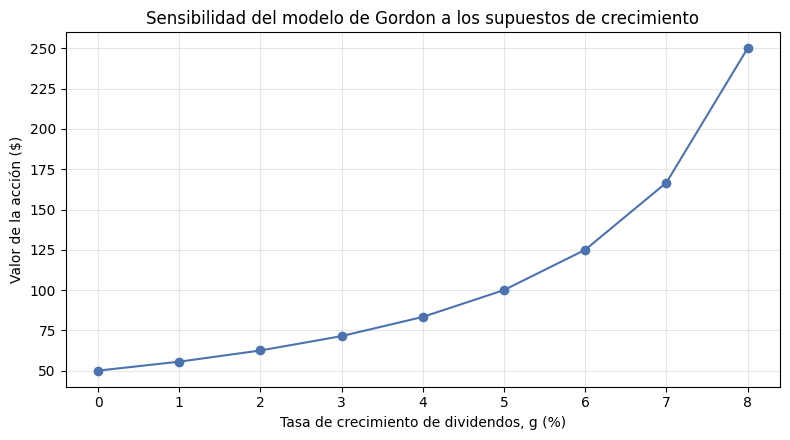

In [15]:
# Sensibilidad del valor de la acción común ante distintos supuestos de crecimiento (g)
tasas_crecimiento = np.arange(0.00, 0.09, 0.01)
valores = [valor_presente_perpetuidad_creciente(5, 0.10, g) for g in tasas_crecimiento]

fig, ax = plt.subplots()
ax.plot(tasas_crecimiento * 100, valores, marker="o", color="#4C72B0")
ax.set_xlabel("Tasa de crecimiento de dividendos, g (%)")
ax.set_ylabel("Valor de la acción ($)")
ax.set_title("Sensibilidad del modelo de Gordon a los supuestos de crecimiento")
plt.tight_layout()
plt.show()


## Equivalencia entre tasa de interés y tasa de descuento

$$
d = \frac{i}{1+i} \qquad\qquad i = \frac{d}{1-d}
$$


In [16]:
def descuento_desde_interes(i):
    '''d = i/(1+i)'''
    return i / (1 + i)


def interes_desde_descuento(d):
    '''i = d/(1-d)'''
    return d / (1 - d)


### Ejercicios (slides)

> ¿Cuál será la tasa de interés equivalente a una tasa de descuento semestral del 7.2%?

> ¿Cuál será la tasa de descuento anual equivalente a una tasa de interés del 12.3%?


In [17]:
i_equiv = interes_desde_descuento(0.072)
d_equiv = descuento_desde_interes(0.123)

print(f"Tasa de interés equivalente a descuento del 7.2%: {i_equiv:.6%}")
print(f"Tasa de descuento equivalente a interés del 12.3%: {d_equiv:.6%}")

assert round(i_equiv, 6) == round(0.077586, 6)
assert round(d_equiv, 6) == round(0.109528, 6)
print("\nOK: coincide con las slides.")


Tasa de interés equivalente a descuento del 7.2%: 7.758621%
Tasa de descuento equivalente a interés del 12.3%: 10.952805%

OK: coincide con las slides.


## Ecuaciones de valor

Una **ecuación de valor** iguala, en una misma fecha focal, el valor de dos (o más)
conjuntos de flujos de efectivo. Es la herramienta detrás de la **reestructuración de
deudas**: sustituir varias obligaciones por una sola, de modo que ambas partes queden en
la misma posición financiera (en valor del dinero en el tiempo).

Procedimiento:
1. Se elige una **fecha focal** (fecha de comparación).
2. Se traen todos los flujos conocidos a esa fecha (usando $VF$ o $VP$, según corresponda).
3. Se despeja el flujo desconocido para que la ecuación quede balanceada.


In [18]:
def pago_unico_equivalente(deudas, tasa_anual, fecha_focal_anios):
    '''Dadas varias deudas [(monto, vencimiento_en_años), ...] y una tasa de interés
    anual (compuesta), regresa el pago único equivalente en la fecha focal indicada
    (también en años) que las sustituye a todas.

    Cada deuda se lleva a la fecha focal: si vence antes, se capitaliza (VF);
    si vence después, se descuenta (VP).
    '''
    total = 0.0
    for monto, vencimiento in deudas:
        n = fecha_focal_anios - vencimiento
        total += monto * (1 + tasa_anual) ** n  # n negativo => descuenta automáticamente
    return total


# Ejemplo: una empresa debe $50,000 en 6 meses y $80,000 en 12 meses. Quiere sustituir
# ambas deudas por un solo pago dentro de 9 meses, a una tasa del 18% anual compuesta.
deudas = [(50_000, 6 / 12), (80_000, 12 / 12)]
pago_equivalente = pago_unico_equivalente(deudas, tasa_anual=0.18, fecha_focal_anios=9 / 12)

print(f"Pago único equivalente en 9 meses: ${pago_equivalente:,.2f}")


Pago único equivalente en 9 meses: $128,869.60


## Caso empresarial integrador: tabla de amortización de un crédito

Con `factor_anualidad_vencida` y las fórmulas de interés compuesto podemos construir una
**tabla de amortización** completa (saldo insoluto, interés, abono a capital) para un
crédito empresarial o hipotecario, tal como la que entregaría un banco.


In [19]:
def tabla_amortizacion(PV, i, n):
    '''Genera la tabla de amortización de un crédito con pagos iguales (sistema francés).'''
    R = renta_desde_pv(PV, i, n)
    saldo = PV
    filas = []
    for periodo in range(1, n + 1):
        interes = saldo * i
        abono_capital = R - interes
        saldo -= abono_capital
        filas.append({
            "Periodo": periodo,
            "Pago": R,
            "Interés": interes,
            "Abono a capital": abono_capital,
            "Saldo insoluto": max(saldo, 0),
        })
    return pd.DataFrame(filas)


credito = tabla_amortizacion(PV=1_000_000, i=0.20 / 12, n=24)
print(f"Pago mensual fijo: ${credito['Pago'].iloc[0]:,.2f}")
credito.round(2).head(6)


Pago mensual fijo: $50,895.80


,Periodo,Pago,Interés,Abono a capital,Saldo insoluto
0,1,"50,895.800000","16,666.670000","34,229.140000","965,770.860000"
1,2,"50,895.800000","16,096.180000","34,799.620000","930,971.240000"
2,3,"50,895.800000","15,516.190000","35,379.620000","895,591.630000"
3,4,"50,895.800000","14,926.530000","35,969.280000","859,622.350000"
4,5,"50,895.800000","14,327.040000","36,568.760000","823,053.590000"
5,6,"50,895.800000","13,717.560000","37,178.240000","785,875.350000"


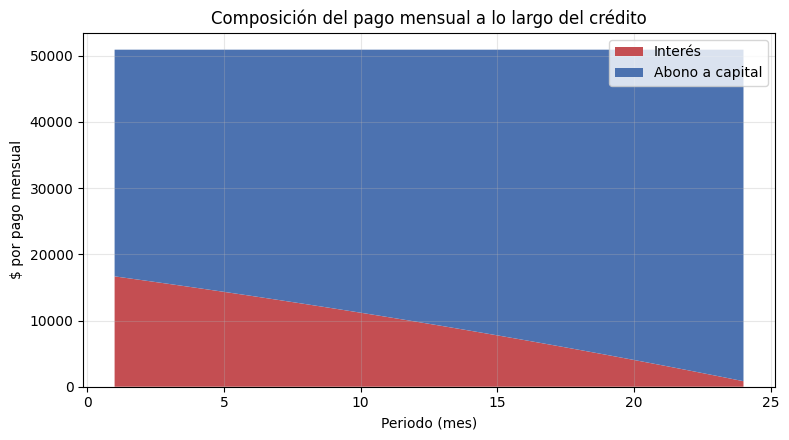

Total pagado: $1,221,499.26
Total de intereses pagados: $221,499.26


In [20]:
fig, ax = plt.subplots()
ax.stackplot(credito["Periodo"], credito["Interés"], credito["Abono a capital"],
             labels=["Interés", "Abono a capital"], colors=["#C44E52", "#4C72B0"])
ax.set_xlabel("Periodo (mes)")
ax.set_ylabel("$ por pago mensual")
ax.set_title("Composición del pago mensual a lo largo del crédito")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"Total pagado: ${credito['Pago'].sum():,.2f}")
print(f"Total de intereses pagados: ${credito['Interés'].sum():,.2f}")


## Caso de inversión integrador: evaluación de un proyecto (VPN) usando anualidades

Cuando un proyecto genera un flujo de efectivo **constante** durante varios periodos,
podemos usar directamente el valor presente de una anualidad para calcular su Valor
Presente Neto (VPN), en vez de descontar flujo por flujo.


In [21]:
def vpn_flujo_constante(inversion_inicial, flujo_anual, i, n):
    '''VPN de un proyecto con flujo de efectivo constante durante n periodos.'''
    return valor_presente_anualidad_vencida(flujo_anual, i, n) - inversion_inicial


proyectos = pd.DataFrame({
    "Proyecto": ["A", "B", "C"],
    "Inversión inicial": [1_000_000, 1_500_000, 800_000],
    "Flujo anual esperado": [260_000, 340_000, 190_000],
    "Vida útil (años)": [6, 7, 6],
})

costo_capital = 0.14
proyectos["VPN"] = proyectos.apply(
    lambda r: vpn_flujo_constante(r["Inversión inicial"], r["Flujo anual esperado"], costo_capital, r["Vida útil (años)"]),
    axis=1,
)
proyectos["¿Aceptar?"] = np.where(proyectos["VPN"] > 0, "Sí", "No")
proyectos.round(2)


,Proyecto,Inversión inicial,Flujo anual esperado,Vida útil (años),VPN,¿Aceptar?
0,A,1000000,260000,6,"11,053.550000",Sí
1,B,1500000,340000,7,"-41,976.350000",No
2,C,800000,190000,6,"-61,153.170000",No


## Resumen de funciones del notebook

| Función | Uso |
|---|---|
| `valor_presente_anualidad_vencida(R, i, n, fv_adicional)` | VP de una anualidad vencida (+ pago único opcional, útil para bonos) |
| `renta_desde_pv(PV, i, n)` / `renta_desde_fv(FV, i, n)` | Despeje de la renta periódica |
| `renta_con_iva(PV, i, n, iva)` | Renta de un crédito reconociendo IVA sobre intereses |
| `valor_presente_anualidad_anticipada(R, i, n)` | VP de una anualidad anticipada |
| `valor_futuro_anualidad_vencida(R, i, n)` / `valor_futuro_anualidad_anticipada(R, i, n)` | VF de anualidades |
| `valor_presente_anualidad_diferida(R, i, n, k)` | VP de una anualidad con periodo de gracia |
| `valor_presente_perpetuidad(pago, i)` | VP de una perpetuidad simple |
| `valor_presente_perpetuidad_creciente(D1, i, g)` | Modelo de Gordon (perpetuidad creciente) |
| `descuento_desde_interes(i)` / `interes_desde_descuento(d)` | Equivalencia tasa de interés ↔ tasa de descuento |
| `pago_unico_equivalente(deudas, tasa, fecha_focal)` | Ecuaciones de valor / reestructura de deudas |
| `tabla_amortizacion(PV, i, n)` | Tabla de amortización de un crédito |
| `vpn_flujo_constante(inv, flujo, i, n)` | VPN de un proyecto con flujo constante |

## Ejercicios propuestos

1. Construye la tabla de amortización de un crédito hipotecario de \$2,500,000 a 15 años
   (180 pagos mensuales) a una tasa del 11.5% anual. ¿Cuánto interés total se paga?
2. Una empresa quiere sustituir tres pagarés (\$100,000 a 3 meses, \$150,000 a 8 meses y
   \$90,000 a 14 meses) por un solo pago dentro de 10 meses, a una tasa del 20% anual.
   Usa `pago_unico_equivalente` para calcularlo.
3. Valúa una acción que se espera pague un dividendo de \$3.20 el próximo año, con
   crecimiento esperado del 5% anual y un costo de capital del 12%. ¿Cómo cambia el valor
   si el crecimiento esperado sube a 7%?
4. Compara dos proyectos de inversión con `vpn_flujo_constante` usando un costo de
   capital del 16% y decide cuál convendría emprender.
